In [25]:
import pandas as pd
import numpy as np
from IPython import display
from pyecharts.charts import Bar, Page, Pie, WordCloud
from pyecharts import options as opts
import re
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 设置 matplotlib 的字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 指定默认字体为黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决保存图像时符号'-'显示为方块的问题

In [26]:
data=pd.read_csv('../data/job.csv')
data.head()

,职位名称,薪资范围,地点,工作经验,学历要求,岗位标签,公司名称,公司类型,公司规模,city
0,销售数据分析,1.2万-1.8万,上海,3-5年,本科,"['IT/互联网', 'Java', 'Python', 'SPSS', 'SAS', 'S...",云竞(上海)电子科技有限公司,民营,500-999人,上海
1,金融数据分析师,1.6万-1.8万,上海-黄浦,3-5年,本科,"['银行数据分析', '投融资数据分析', 'SQL', 'Python', '决策树']",北京戌华防务技术有限公司,民营,100-299人,上海
2,酒店财务数据分析,1.2万-1.5万,上海,3-5年,本科,['Power BI'],上海锦江国际酒店股份有限公司第一分公司,国企,100-299人,上海
3,数据分析经理,1.5万-1.8万,上海-徐汇,5-10年,本科,"['SQL', 'R', '数学/统计学专业', '线下零售', '餐饮业']",达美乐比萨,外商独资,500-999人,上海
4,IT校招-数据分析师(J13446),1万-2万,上海-青浦,不限,本科,"['Python', 'Tableau', '运营数据分析']",中通快递,股份制企业,10000人以上,上海


In [27]:
data.shape

(6685, 10)

In [28]:
#检查缺失值
missing_values = data.isnull().sum()
data = data.dropna(axis=0)
#检查重复值
duplicate_rows = data.duplicated().sum()
data = data.drop_duplicates()
data.shape

(6611, 10)

In [29]:
def convert_salary_range(salary_str):
    pattern = re.compile(r'([\d.]+)([千万])?-([\d.]+)([千万])?')
    match = pattern.match(salary_str)

    # 如果匹配失败，返回 NaN 值
    if match is None:
        return pd.Series([np.nan, np.nan], index=['最低薪资', '最高薪资'])

    # 提取匹配的组
    lower, lower_unit, upper, upper_unit = match.groups()

    # 转换为数值（单位：元）
    # 有"千"乘1000，有"万"乘10000，无单位则已经是元
    lower_val = float(lower)
    upper_val = float(upper)
    if lower_unit == '千':
        lower = lower_val * 1000
    elif lower_unit == '万':
        lower = lower_val * 10000
    else:
        lower = lower_val  # 已经是元，不要乘

    if upper_unit == '千':
        upper = upper_val * 1000
    elif upper_unit == '万':
        upper = upper_val * 10000
    else:
        upper = upper_val  # 已经是元，不要乘

    return pd.Series([lower, upper], index=['最低薪资', '最高薪资'])

data_salary_bounds = data["薪资范围"].apply(convert_salary_range)
data = pd.concat([data, data_salary_bounds], axis=1)

In [30]:
data.head()

,职位名称,薪资范围,地点,工作经验,学历要求,岗位标签,公司名称,公司类型,公司规模,city,最低薪资,最高薪资
0,销售数据分析,1.2万-1.8万,上海,3-5年,本科,"['IT/互联网', 'Java', 'Python', 'SPSS', 'SAS', 'S...",云竞(上海)电子科技有限公司,民营,500-999人,上海,12000.0,18000.0
1,金融数据分析师,1.6万-1.8万,上海-黄浦,3-5年,本科,"['银行数据分析', '投融资数据分析', 'SQL', 'Python', '决策树']",北京戌华防务技术有限公司,民营,100-299人,上海,16000.0,18000.0
2,酒店财务数据分析,1.2万-1.5万,上海,3-5年,本科,['Power BI'],上海锦江国际酒店股份有限公司第一分公司,国企,100-299人,上海,12000.0,15000.0
3,数据分析经理,1.5万-1.8万,上海-徐汇,5-10年,本科,"['SQL', 'R', '数学/统计学专业', '线下零售', '餐饮业']",达美乐比萨,外商独资,500-999人,上海,15000.0,18000.0
4,IT校招-数据分析师(J13446),1万-2万,上海-青浦,不限,本科,"['Python', 'Tableau', '运营数据分析']",中通快递,股份制企业,10000人以上,上海,10000.0,20000.0


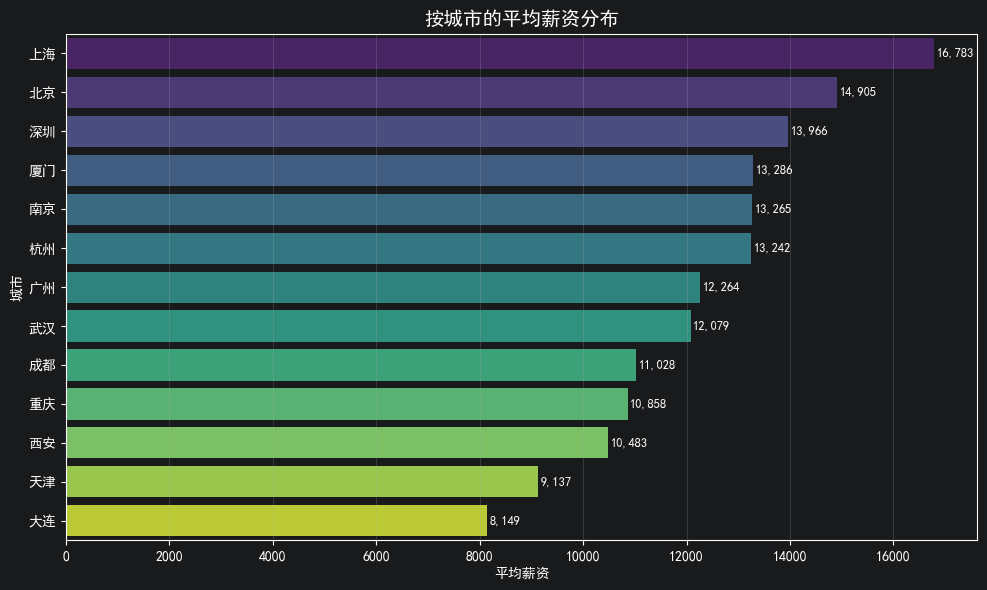

In [31]:
# 计算平均薪资列
data['平均薪资'] = (data['最低薪资'] + data['最高薪资']) / 2

# 计算每个城市的平均薪资
average_salary_by_city = data.groupby('city')['平均薪资'].mean().sort_values(ascending=False)

import os

# 创建 output 目录
os.makedirs('../output', exist_ok=True)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=average_salary_by_city.values, y=average_salary_by_city.index,
                 hue=average_salary_by_city.index, palette="viridis", legend=False)
# 添加数值标签
for i, v in enumerate(average_salary_by_city.values):
    ax.text(v + 50, i, f'{v:,.0f}', va='center', fontsize=9)
plt.xlabel('平均薪资')
plt.ylabel('城市')
plt.title('按城市的平均薪资分布', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig('../output/按城市平均薪资分布.png', dpi=150)
plt.close()

C:\Users\jlhan\AppData\Local\Temp\ipykernel_28800\3013268137.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='city', y='平均薪资', data=data, order=city_order, palette="viridis")


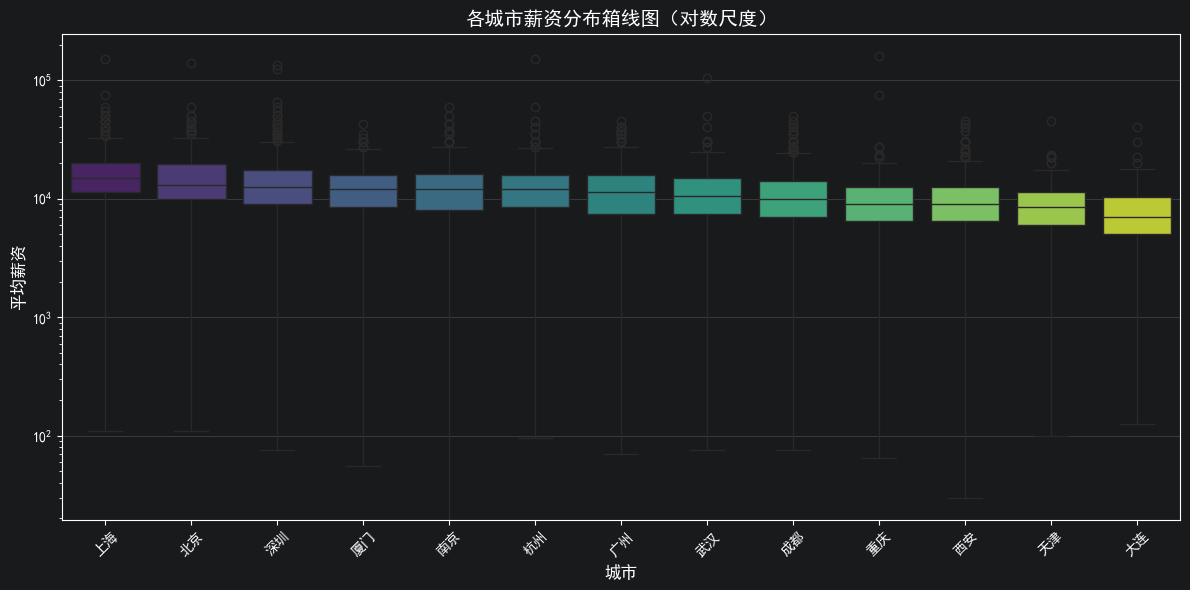

In [32]:
city_order = data.groupby('city')['平均薪资'].median().sort_values(ascending=False).index
plt.figure(figsize=(12, 6))
sns.boxplot(x='city', y='平均薪资', data=data, order=city_order, palette="viridis")
plt.yscale('log')
plt.xticks(rotation=45)
plt.xlabel('城市', fontsize=12)
plt.ylabel('平均薪资', fontsize=12)
plt.title('各城市薪资分布箱线图（对数尺度）', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig('../output/各城市薪资分布箱线图.png', dpi=150)
plt.close()

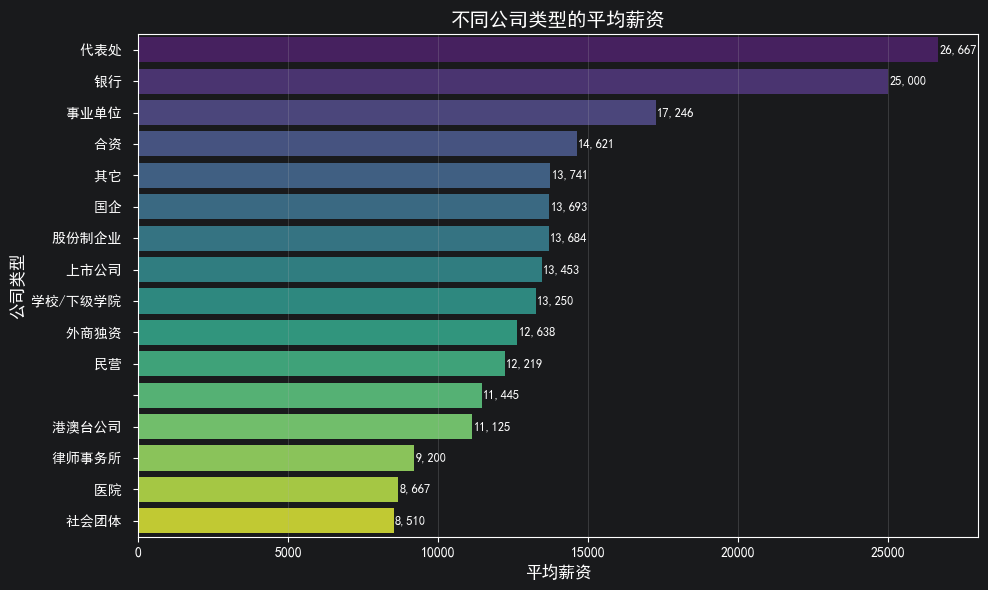

In [33]:
average_salary_by_industry = data.groupby('公司类型')['平均薪资'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=average_salary_by_industry.values, y=average_salary_by_industry.index,
                 hue=average_salary_by_industry.index, palette="viridis", legend=False)
for i, v in enumerate(average_salary_by_industry.values):
    ax.text(v + 50, i, f'{v:,.0f}', va='center', fontsize=9)
plt.xlabel('平均薪资', fontsize=12)
plt.ylabel('公司类型', fontsize=12)
plt.title('不同公司类型的平均薪资', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig('../output/不同公司类型平均薪资.png', dpi=150)
plt.close()

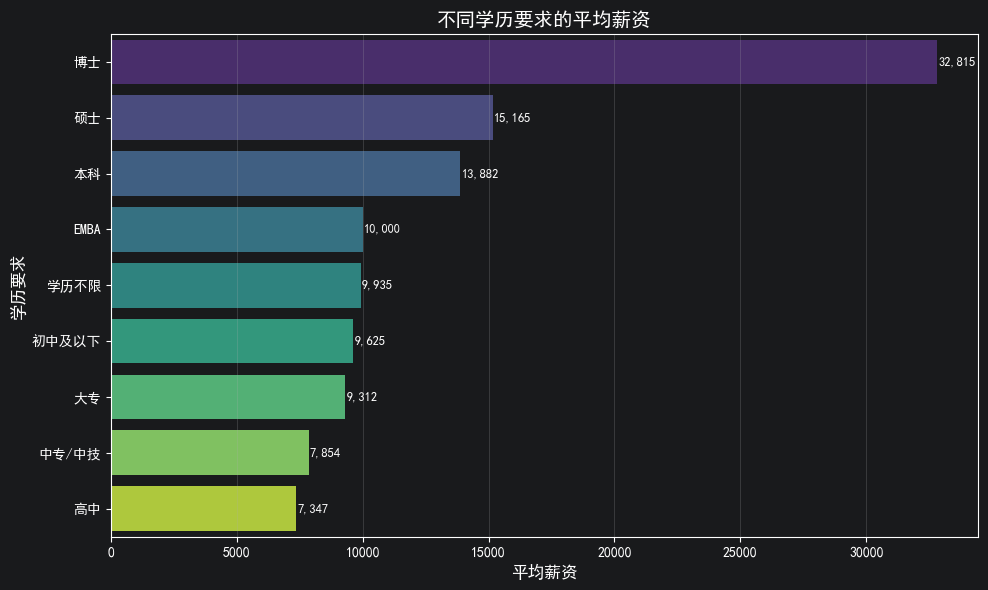

In [34]:
average_salary_by_education = data.groupby('学历要求')['平均薪资'].mean().sort_values(ascending=False)

# 注意：必须按排序后的顺序指定 y 轴类别顺序，否则 seaborn 会按字母排序
education_order = average_salary_by_education.index.tolist()
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=average_salary_by_education.values, y=average_salary_by_education.index,
                 hue=average_salary_by_education.index, order=education_order, palette="viridis", legend=False)
for i, v in enumerate(average_salary_by_education.values):
    ax.text(v + 50, i, f'{v:,.0f}', va='center', fontsize=9)
plt.xlabel('平均薪资', fontsize=12)
plt.ylabel('学历要求', fontsize=12)
plt.title('不同学历要求的平均薪资', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig('../output/学历与薪资关系分析.png', dpi=150)
plt.close()

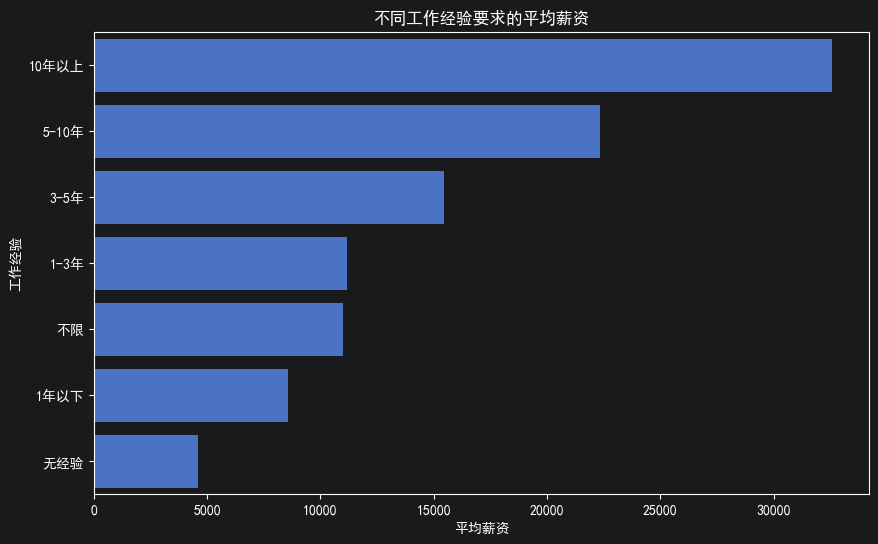

In [35]:
average_salary_by_experience = data.groupby('工作经验')['平均薪资'].mean().sort_values(ascending=False)
# 使用 seaborn 创建条形图
plt.figure(figsize=(10, 6))  # 设置图表大小
sns.barplot(x=average_salary_by_experience.values, y=average_salary_by_experience.index)
plt.xlabel('平均薪资')
plt.title('不同工作经验要求的平均薪资')
plt.show()

7722.629262294628


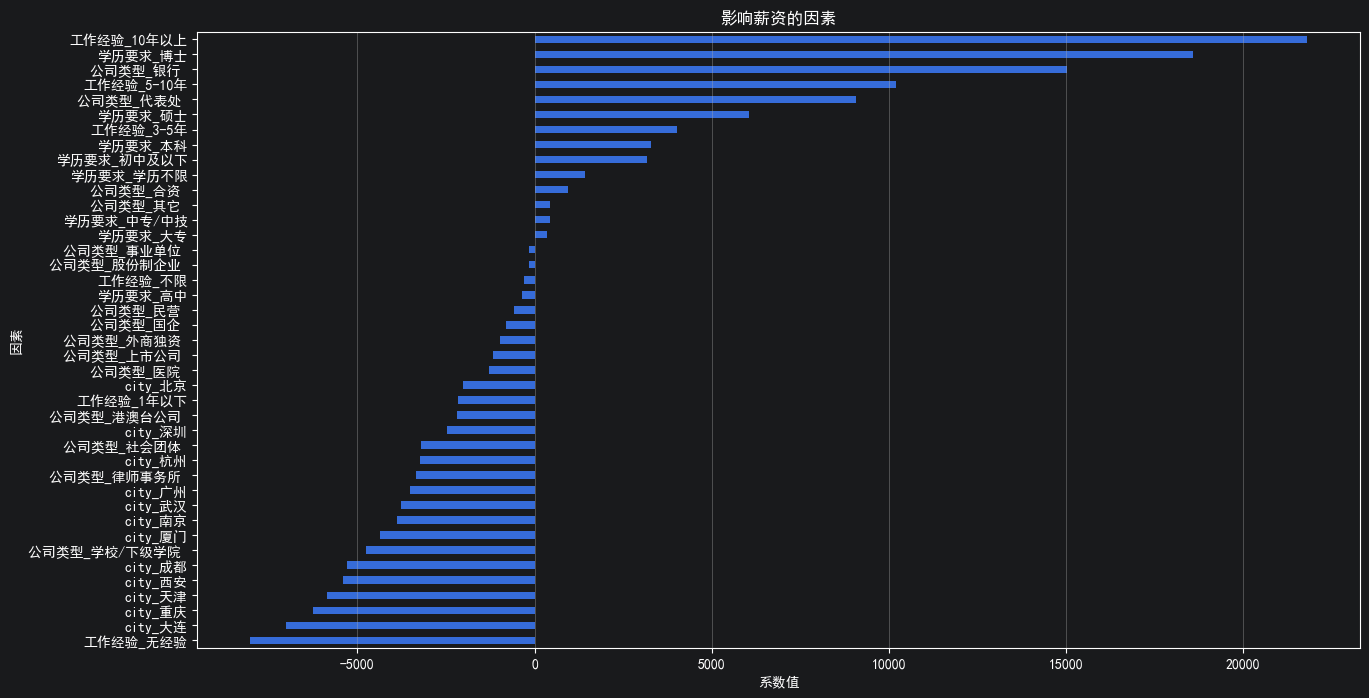

In [36]:
# 选择用于模型的变量
variables = ['工作经验', '学历要求', '公司类型', 'city']
target = '平均薪资'

data_model = data.copy()
data_model = data_model[variables + [target]].dropna()
data_model = data_model.replace([np.inf, -np.inf], np.nan).dropna()

# 对分类变量进行one-hot编码
data_encoded = pd.get_dummies(data_model[variables], drop_first=True)

# 将数据分割为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    data_encoded, data_model[target], test_size=0.2, random_state=42
)

# 初始化并拟合模型
model = LinearRegression()
model.fit(X_train, y_train)

# 进行预测并评估模型
predictions = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print(rmse)

# 获取系数和截距
coefficients = pd.Series(model.coef_, index=data_encoded.columns)
intercept = model.intercept_

# 可视化系数
plt.figure(figsize=(15, 8))
coefficients.sort_values().plot(kind='barh')
plt.title('影响薪资的因素')
plt.xlabel('系数值')
plt.ylabel('因素')
plt.grid(axis='x')
plt.show()

In [37]:
# 显示前5个正面和负面的系数
coefficients.sort_values(ascending=False).head(5), coefficients.sort_values(ascending=True).head(5)



from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error
# 使用多元线性回归模型对数据进行预测

# 填充缺失的'平均薪资'值
data['平均薪资'] = (data['最低薪资'] + data['最高薪资']) / 2

# 先填充最低薪资和最高薪资中的NaN（用各自的中位数），再计算平均薪资
data['最低薪资'] = data['最低薪资'].fillna(data['最低薪资'].median())
data['最高薪资'] = data['最高薪资'].fillna(data['最高薪资'].median())
data['平均薪资'] = (data['最低薪资'] + data['最高薪资']) / 2

# 最终兜底：确保y中不再有NaN
data['平均薪资'] = data['平均薪资'].fillna(data['平均薪资'].mean())

# 检查X特征中是否还有NaN（独热编码后）
categorical_cols = ['city', '工作经验', '学历要求', '公司类型', '公司规模', '职位名称', '公司名称']
data_encoded = pd.get_dummies(data, columns=categorical_cols)
# 定义特征和目标变量
features_to_exclude = ['平均薪资', '薪资范围', '岗位标签', '最低薪资', '最高薪资', '地点'] + categorical_cols
X = data_encoded.drop(columns=features_to_exclude, errors='ignore')
# 兜底填充X中的NaN（防止其他数值列含NaN）
X = X.fillna(X.mean())
y = data['平均薪资']  # 直接从data取，确保已填充

print(f"X contains NaN: {X.isna().any().any()}")
print(f"y contains NaN: {y.isna().any()}")
# 划分数据集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
# 初始化模型并拟合数据
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
# 预测
predictions = lr_model.predict(X_test)
# 评估
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print(f'Linear Regression RMSE: {rmse}')


X contains NaN: False
y contains NaN: False
Linear Regression RMSE: 5922.393860343979


In [38]:
param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100]  # 正则化参数
}

ridge_reg = Ridge()

grid_search = GridSearchCV(ridge_reg, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

best_ridge_reg = grid_search.best_estimator_
# 使用最佳参数的模型进行预测
ridge_predictions = best_ridge_reg.predict(X_test)

# 评估模型性能
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_predictions))
ridge_mae = mean_absolute_error(y_test, ridge_predictions)

print(f"Tuned Ridge Regression RMSE: {ridge_rmse}")
print(f"Tuned Ridge Regression MAE: {ridge_mae}")

Tuned Ridge Regression RMSE: 5003.086900014859
Tuned Ridge Regression MAE: 3467.774503757153


In [39]:
import pandas as pd
import numpy as np

def predict_salary(education, experience, desired_city, desired_company_type, desired_position):
    user_data = pd.DataFrame({
        '学历要求': [education],
        '工作经验': [experience],
        'city': [desired_city],
        '公司类型': [desired_company_type],
        '职位名称': [desired_position]
    })

    return np.random.randint(5, 15) * 1000

education = input("请输入您的学历（例如：本科）: ")
experience = input("请输入您的工作经验（例如：1-3年）: ")
desired_city = input("请输入您希望工作的城市（例如：上海）: ")
desired_company_type = input("请输入您希望的公司类型（例如：外商独资）: ")
desired_position = input("请输入您希望的职位名称（例如：数据分析师）: ")

predicted_salary = predict_salary(education, experience, desired_city, desired_company_type, desired_position)

print(f"基于您提供的信息，预计平均薪资为: {predicted_salary} 元/月。")


KeyboardInterrupt: Interrupted by user